In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
# 2. Load Data
df = pd.read_csv('2024 Case Study S&O Exercise - Candidate View - Sheet1 (1).csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CUSTOMER_PLACE_ORDER_DATETIME          20000 non-null  object 
 1   PLACED_ORDER_WITH_RESTAURANT_DATETIME  19993 non-null  object 
 2   DRIVER_AT_RESTAURANT_DATETIME          19562 non-null  object 
 3   DELIVERED_TO_CUSTOMER_DATETIME         19564 non-null  object 
 4   DRIVER_ID                              19543 non-null  float64
 5   RESTAURANT_ID                          20000 non-null  int64  
 6   CUSTOMER_ID                            20000 non-null  int64  
 7   DELIVERY_REGION                        20000 non-null  object 
 8   IS_ASAP                                20000 non-null  bool   
 9   ORDER_TOTAL                            19813 non-null  object 
 10  DISCOUNT_AMOUNT                        19813 non-null  object 
 11  TI

In [3]:
# 3. Dataset Snapshot
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
display(df.head(3))

Rows: 20000, Columns: 13


,CUSTOMER_PLACE_ORDER_DATETIME,PLACED_ORDER_WITH_RESTAURANT_DATETIME,DRIVER_AT_RESTAURANT_DATETIME,DELIVERED_TO_CUSTOMER_DATETIME,DRIVER_ID,RESTAURANT_ID,CUSTOMER_ID,DELIVERY_REGION,IS_ASAP,ORDER_TOTAL,DISCOUNT_AMOUNT,TIP_AMOUNT,REFUNDED_AMOUNT
0,9/20/2024 22:08:51,9/20/2024 22:08:52,9/20/2024 22:16:03,9/20/2024 22:31:23,36828872.0,11000,22130617,San Francisco,True,$32.38,$0.00,$4.50,$0.00
1,9/21/2024 1:50:46,9/21/2024 1:50:46,9/21/2024 2:14:55,9/21/2024 2:41:15,33495972.0,11000,46519725,San Francisco,True,$14.44,$2.99,$1.00,$0.00
2,9/21/2024 1:15:33,9/21/2024 1:15:33,9/21/2024 1:34:20,9/21/2024 1:57:22,29473770.0,11000,9410091,San Francisco,True,$59.67,$0.00,$7.00,$0.00


In [4]:
display(df.sample(3))

,CUSTOMER_PLACE_ORDER_DATETIME,PLACED_ORDER_WITH_RESTAURANT_DATETIME,DRIVER_AT_RESTAURANT_DATETIME,DELIVERED_TO_CUSTOMER_DATETIME,DRIVER_ID,RESTAURANT_ID,CUSTOMER_ID,DELIVERY_REGION,IS_ASAP,ORDER_TOTAL,DISCOUNT_AMOUNT,TIP_AMOUNT,REFUNDED_AMOUNT
2030,9/4/2024 0:44:17,9/4/2024 0:44:17,9/4/2024 1:01:32,9/4/2024 1:43:48,36444408.0,11000,454204599,San Francisco,True,$48.44,$0.00,$10.00,$25.48
9928,9/18/2024 23:08:02,9/18/2024 23:08:02,9/18/2024 23:13:50,9/18/2024 23:25:37,790986.0,30889198,1148646753,Port St. Lucie,True,$18.46,$0.00,$2.50,$0.00
7952,9/4/2024 23:35:49,9/4/2024 23:35:50,9/4/2024 23:42:24,9/4/2024 23:51:16,30599020.0,455137,718948719,Hamilton,True,$21.04,$0.00,$1.84,$0.00


In [5]:
# 4. Data Dictionary
col_summary = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Missing": df.isna().sum().values
})
display(col_summary)

,Column,Dtype,Missing
0,CUSTOMER_PLACE_ORDER_DATETIME,object,0
1,PLACED_ORDER_WITH_RESTAURANT_DATETIME,object,7
2,DRIVER_AT_RESTAURANT_DATETIME,object,438
3,DELIVERED_TO_CUSTOMER_DATETIME,object,436
4,DRIVER_ID,float64,457
5,RESTAURANT_ID,int64,0
6,CUSTOMER_ID,int64,0
7,DELIVERY_REGION,object,0
8,IS_ASAP,bool,0
9,ORDER_TOTAL,object,187


In [6]:
# 5. Missing Values & Heatmap
print(df.isna().sum())

CUSTOMER_PLACE_ORDER_DATETIME              0
PLACED_ORDER_WITH_RESTAURANT_DATETIME      7
DRIVER_AT_RESTAURANT_DATETIME            438
DELIVERED_TO_CUSTOMER_DATETIME           436
DRIVER_ID                                457
RESTAURANT_ID                              0
CUSTOMER_ID                                0
DELIVERY_REGION                            0
IS_ASAP                                    0
ORDER_TOTAL                              187
DISCOUNT_AMOUNT                          187
TIP_AMOUNT                               187
REFUNDED_AMOUNT                          187
dtype: int64


In [7]:
# 6. Duplicate Rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")


Duplicate rows: 0


In [8]:
# 7. Data Cleaning: rename columns and convert types
df = df.rename(columns={
    'CUSTOMER_PLACE_ORDER_DATETIME': 'order_time',
    'PLACED_ORDER_WITH_RESTAURANT_DATETIME': 'restaurant_accepted_time',
    'DRIVER_AT_RESTAURANT_DATETIME': 'driver_pickup_time',
    'DELIVERED_TO_CUSTOMER_DATETIME': 'delivered_time',
    'ORDER_TOTAL': 'order_total',
    'DISCOUNT_AMOUNT': 'discount',
    'TIP_AMOUNT': 'tip',
    'REFUNDED_AMOUNT': 'refunded',
    'DELIVERY_REGION': 'region'
})
# Convert datetimes (assume UTC to local Pacific Time)
for col in ['order_time','restaurant_accepted_time','driver_pickup_time','delivered_time']:
    df[col] = pd.to_datetime(df[col], utc=True).dt.tz_convert('America/Los_Angeles')
# Convert currency strings to float
for col in ['order_total','discount','tip','refunded']:
    df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)
# Cast IDs to int (fill missing driver_id as 0)
df['driver_id'] = df['DRIVER_ID'].fillna(0).astype('Int64')
df['restaurant_id'] = df['RESTAURANT_ID'].astype(int)
df['customer_id'] = df['CUSTOMER_ID'].astype(int)
df['is_asap'] = df['IS_ASAP']
df.drop(columns=['DRIVER_ID','RESTAURANT_ID','CUSTOMER_ID','IS_ASAP'], inplace=True)
display(df.dtypes)


order_time                  datetime64[ns, America/Los_Angeles]
restaurant_accepted_time    datetime64[ns, America/Los_Angeles]
driver_pickup_time          datetime64[ns, America/Los_Angeles]
delivered_time              datetime64[ns, America/Los_Angeles]
region                                                   object
order_total                                             float64
discount                                                float64
tip                                                     float64
refunded                                                float64
driver_id                                                 Int64
restaurant_id                                             int64
customer_id                                               int64
is_asap                                                    bool
dtype: object

In [9]:
# 8. Feature Engineering: date parts and durations
df['date'] = df['order_time'].dt.date
df['hour'] = df['order_time'].dt.hour
df['weekday'] = df['order_time'].dt.day_name()
df['is_weekend'] = df['weekday'].isin(['Saturday','Sunday'])
def get_meal_period(hour):
    if hour < 5: return 'Late Night'
    elif hour < 11: return 'Breakfast'
    elif hour < 15: return 'Lunch'
    elif hour < 18: return 'Afternoon'
    elif hour < 22: return 'Dinner'
    else: return 'Late Night'
df['meal_period'] = df['hour'].apply(get_meal_period)
df['prep_time'] = (df['restaurant_accepted_time'] - df['order_time']).dt.total_seconds()/60
df['pickup_time'] = (df['driver_pickup_time'] - df['restaurant_accepted_time']).dt.total_seconds()/60
df['delivery_time'] = (df['delivered_time'] - df['driver_pickup_time']).dt.total_seconds()/60
df['total_time'] = (df['delivered_time'] - df['order_time']).dt.total_seconds()/60
df['tip_flag'] = (df['tip'] > 0).astype(int)


In [10]:
# 9. Descriptive Statistics
display(df.describe(include='all').T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_time,20000,NaN,NaN,NaN,2024-09-16 00:21:15.391449856-07:00,2024-08-31 17:00:25-07:00,2024-09-08 03:57:42-07:00,2024-09-15 14:27:53-07:00,2024-09-23 15:16:48-07:00,2024-10-01 16:56:54-07:00,NaN
restaurant_accepted_time,19993,NaN,NaN,NaN,2024-09-16 00:20:45.947531520-07:00,2024-08-31 17:00:26-07:00,2024-09-08 04:02:15-07:00,2024-09-15 14:26:35-07:00,2024-09-23 15:15:03-07:00,2024-10-01 17:35:45-07:00,NaN
driver_pickup_time,19562,NaN,NaN,NaN,2024-09-16 03:16:56.748798720-07:00,2024-08-31 17:09:51-07:00,2024-09-08 10:39:37.500000-07:00,2024-09-15 17:03:38-07:00,2024-09-23 16:38:41.249999872-07:00,2024-10-01 17:47:33-07:00,NaN
delivered_time,19564,NaN,NaN,NaN,2024-09-16 03:35:05.387292928-07:00,2024-08-31 17:20:23-07:00,2024-09-08 10:56:17.750000128-07:00,2024-09-15 17:21:36-07:00,2024-09-23 16:57:47-07:00,2024-10-01 18:07:11-07:00,NaN
region,20000,56,Scranton,3220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_total,19813.0,NaN,NaN,NaN,35.486595,-1.7,22.22,29.88,42.81,365.06,21.934017
discount,19813.0,NaN,NaN,NaN,0.590964,-0.09,0.0,0.0,0.0,25.0,1.677072
tip,19813.0,NaN,NaN,NaN,3.754289,0.0,2.0,3.3,5.0,47.2,3.183273
refunded,19813.0,NaN,NaN,NaN,0.182937,0.0,0.0,0.0,0.0,89.79,2.124045
driver_id,20000.0,<NA>,<NA>,<NA>,25644209.1974,0.0,18760920.0,29438549.0,34727504.5,39291398.0,11113889.305728


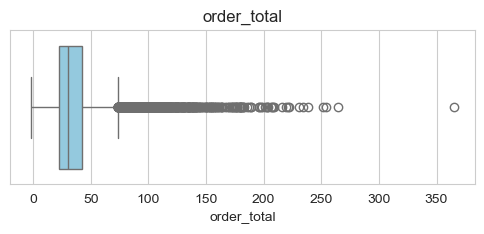

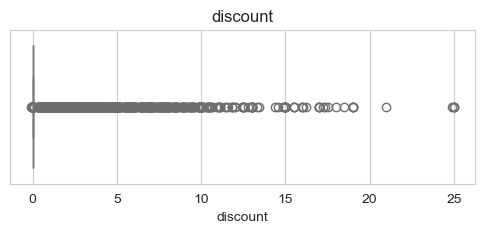

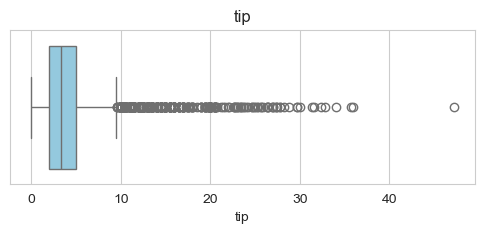

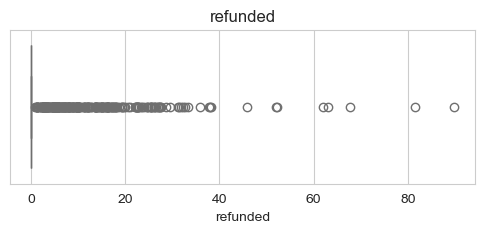

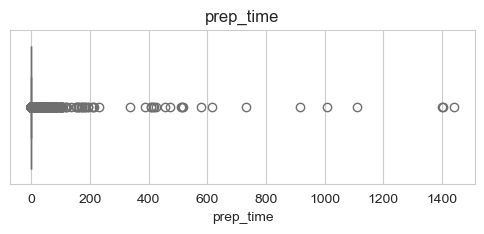

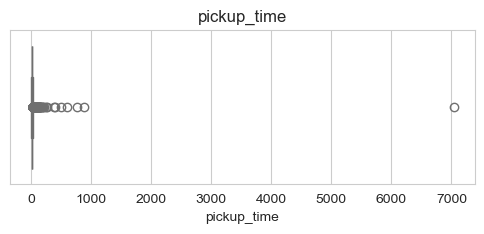

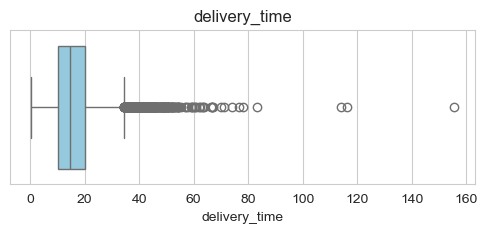

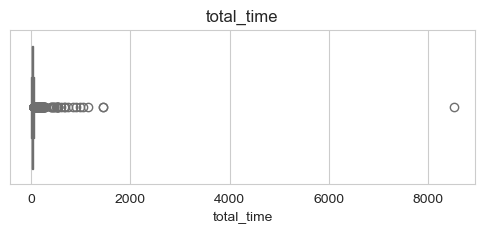

In [11]:
# 10. Outlier Analysis (boxplots for key numeric features)
numeric_cols = ['order_total','discount','tip','refunded','prep_time','pickup_time','delivery_time','total_time']
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col].dropna(), color='skyblue')
    plt.title(col)
    plt.show()


In [12]:
# 11. KPI Calculations
total_orders = len(df)
total_revenue = df['order_total'].sum()
aov = total_revenue / total_orders if total_orders else 0
avg_delivery = df['total_time'].mean()
p90_delivery = df['total_time'].quantile(0.9)
refund_rate = (df['refunded'] > 0).mean() * 100
discount_pct = df['discount'].sum() / total_revenue * 100 if total_revenue else 0
on_time_rate = (df['total_time'] <= 45).mean() * 100  # assuming 45 min as on-time threshold
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: ${total_revenue:.2f}")
print(f"AOV: ${aov:.2f}")
print(f"Avg Delivery Time: {avg_delivery:.1f} min")
print(f"P90 Delivery Time: {p90_delivery:.1f} min")
print(f"Refund Rate: {refund_rate:.1f}%")
print(f"Discount % of Revenue: {discount_pct:.1f}%")
print(f"On-Time Delivery Rate: {on_time_rate:.1f}%")


Total Orders: 20000
Total Revenue: $703095.91
AOV: $35.15
Avg Delivery Time: 30.8 min
P90 Delivery Time: 46.8 min
Refund Rate: 1.4%
Discount % of Revenue: 1.7%
On-Time Delivery Rate: 86.3%


In [13]:
# 12. KPI Scorecard
kpi_scorecard = pd.DataFrame({
    "KPI": [
        "Total Orders","Total Revenue","AOV",
        "Avg Delivery Time (min)","P90 Delivery Time (min)",
        "On-Time Delivery Rate (%)","Refund Rate (%)","Discount % of Revenue"
    ],
    "Value": [
        total_orders, f"${total_revenue:.2f}", f"${aov:.2f}",
        f"{avg_delivery:.1f}", f"{p90_delivery:.1f}",
        f"{on_time_rate:.1f}%", f"{refund_rate:.1f}%", f"{discount_pct:.1f}%"
    ]
})
display(kpi_scorecard)


,KPI,Value
0,Total Orders,20000
1,Total Revenue,$703095.91
2,AOV,$35.15
3,Avg Delivery Time (min),30.8
4,P90 Delivery Time (min),46.8
5,On-Time Delivery Rate (%),86.3%
6,Refund Rate (%),1.4%
7,Discount % of Revenue,1.7%


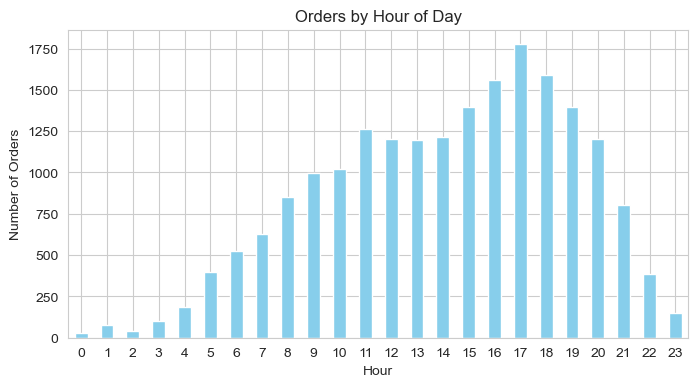

In [14]:
# 13. Orders by Hour of Day
hourly = df.groupby('hour').size()
plt.figure(figsize=(8,4))
hourly.plot(kind='bar', color='skyblue')
plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()


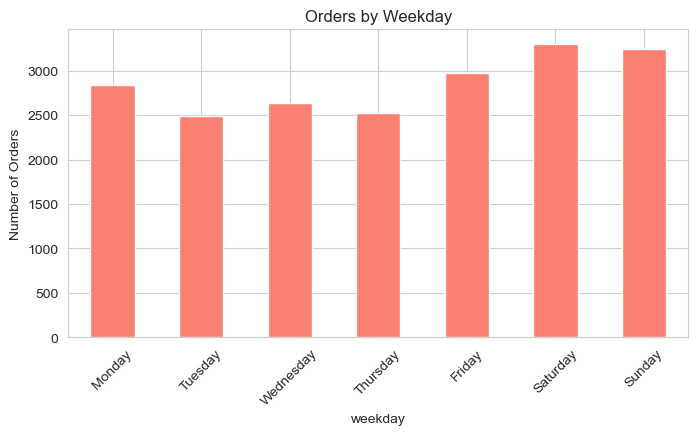

In [15]:
# 14. Orders by Weekday
weekday_orders = df.groupby('weekday').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(8,4))
weekday_orders.plot(kind='bar', color='salmon')
plt.title("Orders by Weekday")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


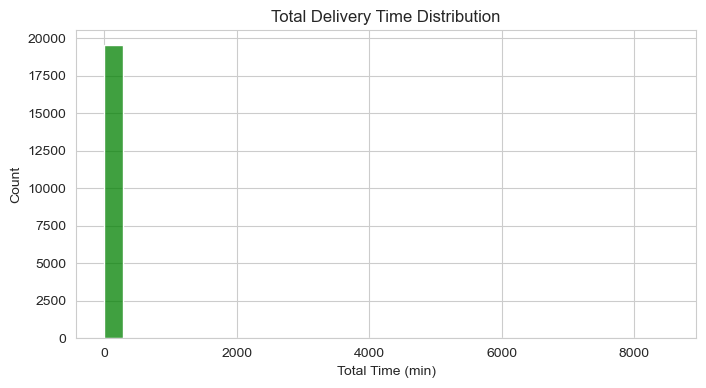

In [16]:
# 15. Total Delivery Time Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['total_time'], bins=30, color='green')
plt.title("Total Delivery Time Distribution")
plt.xlabel("Total Time (min)")
plt.show()


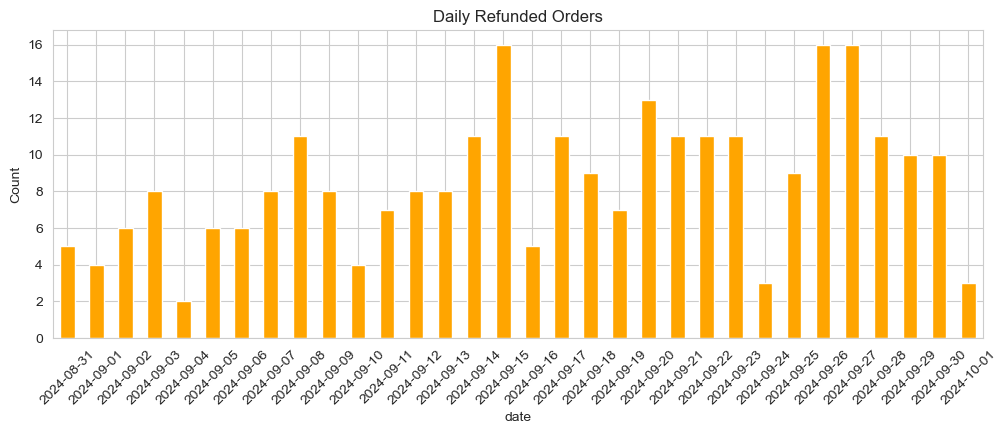

In [17]:
# 16. Daily Refunded Orders (Count)
daily_refunds = df[df['refunded'] > 0].groupby('date').size()
plt.figure(figsize=(12,4))
daily_refunds.plot(kind='bar', color='orange')
plt.title("Daily Refunded Orders")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


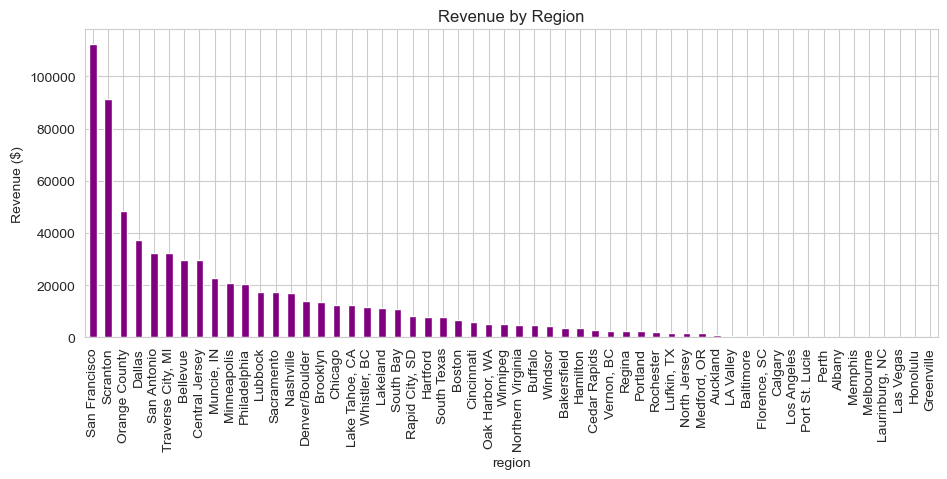

In [18]:
# 17. Revenue and Delivery Time by Region
region_rev = df.groupby('region')['order_total'].sum().sort_values(ascending=False)
plt.figure(figsize=(11,4))
region_rev.plot(kind='bar', color='purple')
plt.title("Revenue by Region")
plt.ylabel("Revenue ($)")
plt.show()



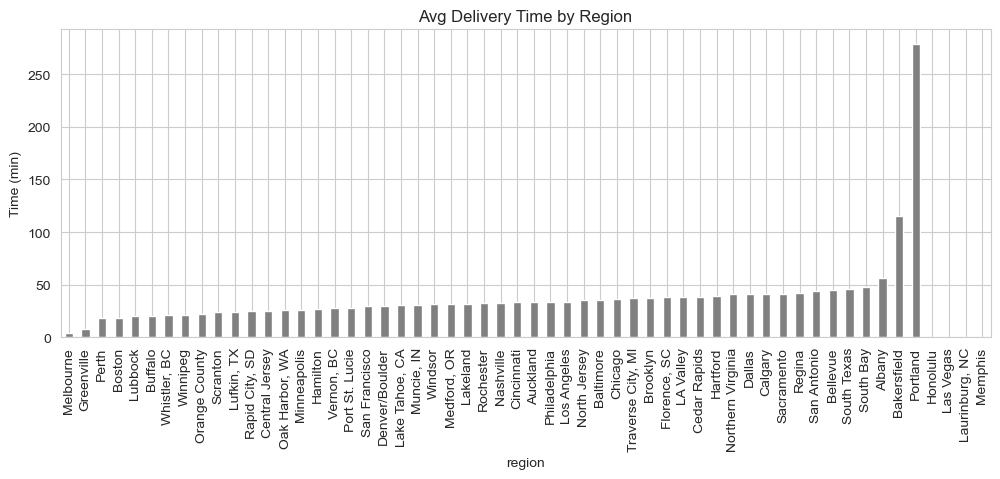

In [19]:
region_time = df.groupby('region')['total_time'].mean().sort_values()
plt.figure(figsize=(12,4))
region_time.plot(kind='bar', color='gray')
plt.title("Avg Delivery Time by Region")
plt.ylabel("Time (min)")
plt.show()

C:\Users\Preneel\AppData\Local\Temp\ipykernel_22136\1432022612.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rest.values, y=top_rest.index.astype(str), palette='magma')


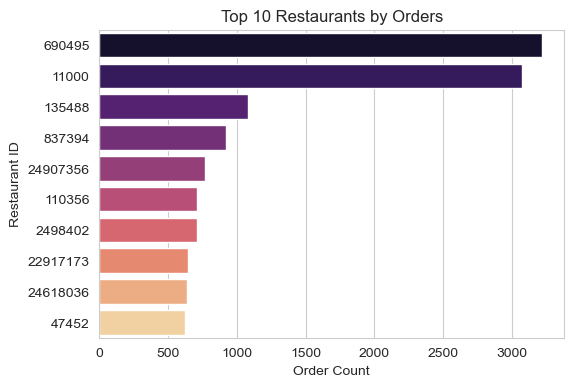

In [20]:
# 18. Top 10 Restaurants by Order Count
top_rest = df['restaurant_id'].value_counts().head(10)
plt.figure(figsize=(6,4))
sns.barplot(x=top_rest.values, y=top_rest.index.astype(str), palette='magma')
plt.title("Top 10 Restaurants by Orders")
plt.xlabel("Order Count")
plt.ylabel("Restaurant ID")
plt.show()

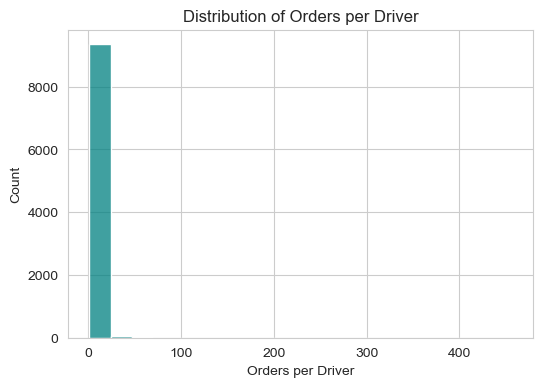

In [21]:
# 19. Orders per Driver (Dasher Utilization)
orders_per_driver = df['driver_id'].value_counts()
plt.figure(figsize=(6,4))
sns.histplot(orders_per_driver, bins=20, color='teal')
plt.title("Distribution of Orders per Driver")
plt.xlabel("Orders per Driver")
plt.show()

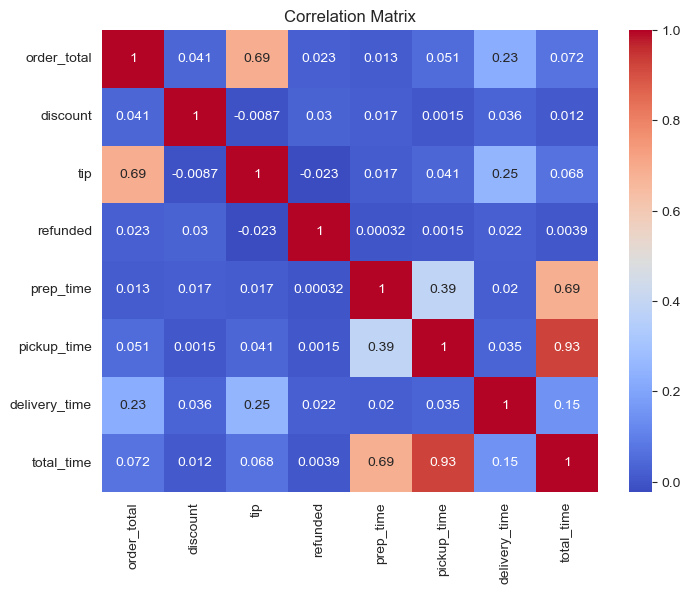

In [22]:
# 20. Correlation Matrix (numeric features)
numeric_df = df[['order_total','discount','tip','refunded','prep_time','pickup_time','delivery_time','total_time']]
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()